# Data sanity checks

Two dataset families, different schemas:
- **MTS-Dialog**: `ID, section_header, section_text, dialogue`
- **ACI-bench**: `dataset, encounter_id, dialogue, note`

Checks per split: size, dtypes, missing values (NaN / None / empty-or-whitespace strings), duplicate rows, inf in numeric cols, and text-length stats.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

DB = Path.cwd()  # run from data_hand/DB

# label -> csv path
FILES = {
    "MTS/train": DB / "training/MTS/MTS-Dialog-TrainingSet.csv",
    "MTS/valid": DB / "valid/MTS/MTS-Dialog-ValidationSet.csv",
    "MTS/test1": DB / "testing/MTS/MTS-Dialog-TestSet-1-MEDIQA-Chat-2023.csv",
    "MTS/test2": DB / "testing/MTS/MTS-Dialog-TestSet-2-MEDIQA-Sum-2023.csv",
    "ACI/train":       DB / "training/aci/train.csv",
    "ACI/taskB_test1":  DB / "training/aci/clinicalnlp_taskB_test1.csv",
    "ACI/taskC_test2":  DB / "training/aci/clinicalnlp_taskC_test2.csv",
    "ACI/valid":        DB / "valid/aci/valid.csv",
    "ACI/test":         DB / "testing/aci/clef_taskC_test3.csv",
}

dfs = {name: pd.read_csv(p) for name, p in FILES.items()}
for name, df in dfs.items():
    print(f"{name:18s} {df.shape[0]:>5} rows x {df.shape[1]} cols  ->  {list(df.columns)}")

# Role tags: which ACI splits feed QLoRA fine-tuning (train_pool) vs. stay held
# out untouched until final evaluation (frozen_test).
ACI_ROLE = {
    "ACI/train": "train_pool",
    "ACI/taskB_test1": "train_pool",
    "ACI/taskC_test2": "train_pool",
    "ACI/valid": "train_pool",
    "ACI/test": "frozen_test",
}

train_pool_rows = sum(len(dfs[n]) for n, r in ACI_ROLE.items() if r == "train_pool")
frozen_rows = sum(len(dfs[n]) for n, r in ACI_ROLE.items() if r == "frozen_test")
assert train_pool_rows == 167, f"expected 167 train_pool ACI rows, got {train_pool_rows}"
assert frozen_rows == 40, f"expected 40 frozen_test ACI rows, got {frozen_rows}"

role_summary = pd.DataFrame(
    {"split": n, "role": r, "rows": len(dfs[n])} for n, r in ACI_ROLE.items()
)
print("\nACI role tags (train_pool feeds fine-tuning, frozen_test is never touched until final eval):")
role_summary

MTS/train           1201 rows x 4 cols  ->  ['ID', 'section_header', 'section_text', 'dialogue']
MTS/valid            100 rows x 4 cols  ->  ['ID', 'section_header', 'section_text', 'dialogue']
MTS/test1            200 rows x 4 cols  ->  ['ID', 'section_header', 'section_text', 'dialogue']
MTS/test2            200 rows x 4 cols  ->  ['ID', 'section_header', 'section_text', 'dialogue']
ACI/train             67 rows x 4 cols  ->  ['dataset', 'encounter_id', 'dialogue', 'note']
ACI/taskB_test1       40 rows x 4 cols  ->  ['dataset', 'encounter_id', 'dialogue', 'note']
ACI/taskC_test2       40 rows x 4 cols  ->  ['dataset', 'encounter_id', 'dialogue', 'note']
ACI/valid             20 rows x 4 cols  ->  ['dataset', 'encounter_id', 'dialogue', 'note']
ACI/test              40 rows x 4 cols  ->  ['dataset', 'encounter_id', 'dialogue', 'note']

ACI role tags (train_pool feeds fine-tuning, frozen_test is never touched until final eval):


,split,role,rows
0,ACI/train,train_pool,67
1,ACI/taskB_test1,train_pool,40
2,ACI/taskC_test2,train_pool,40
3,ACI/valid,train_pool,20
4,ACI/test,frozen_test,40


In [2]:
def check(name, df):
    """Return a one-row summary; print any problems found."""
    n = len(df)
    # missing = real NaN/None OR string that is empty / whitespace-only
    blank = df.apply(lambda c: c.isna() | (c.astype(str).str.strip() == ""))
    missing = blank.sum()

    num = df.select_dtypes(include=[np.number])
    inf_count = int(np.isinf(num.to_numpy()).sum()) if not num.empty else 0

    dup = int(df.duplicated().sum())

    problems = []
    for col, m in missing.items():
        if m:
            problems.append(f"  missing in '{col}': {m}")
    if inf_count:
        problems.append(f"  inf values: {inf_count}")
    if dup:
        problems.append(f"  duplicate rows: {dup}")

    print(f"=== {name}  ({n} rows) ===")
    print(df.dtypes.to_string())
    print("\n".join(problems) if problems else "  OK: no missing / inf / dup")
    print()

    return {"split": name, "rows": n, "cols": df.shape[1],
            "missing_total": int(missing.sum()), "inf": inf_count, "dups": dup}

summary = pd.DataFrame(check(name, df) for name, df in dfs.items())
summary

=== MTS/train  (1201 rows) ===
ID                int64
section_header      str
section_text        str
dialogue            str
  OK: no missing / inf / dup

=== MTS/valid  (100 rows) ===
ID                int64
section_header      str
section_text        str
dialogue            str
  OK: no missing / inf / dup

=== MTS/test1  (200 rows) ===
ID                int64
section_header      str
section_text        str
dialogue            str
  OK: no missing / inf / dup

=== MTS/test2  (200 rows) ===
ID                int64
section_header      str
section_text        str
dialogue            str
  OK: no missing / inf / dup

=== ACI/train  (67 rows) ===
dataset         str
encounter_id    str
dialogue        str
note            str
  OK: no missing / inf / dup

=== ACI/taskB_test1  (40 rows) ===
dataset         str
encounter_id    str
dialogue        str
note            str
  OK: no missing / inf / dup

=== ACI/taskC_test2  (40 rows) ===
dataset         str
encounter_id    str
dialogue        

,split,rows,cols,missing_total,inf,dups
0,MTS/train,1201,4,0,0,0
1,MTS/valid,100,4,0,0,0
2,MTS/test1,200,4,0,0,0
3,MTS/test2,200,4,0,0,0
4,ACI/train,67,4,0,0,0
5,ACI/taskB_test1,40,4,0,0,0
6,ACI/taskC_test2,40,4,0,0,0
7,ACI/valid,20,4,0,0,0
8,ACI/test,40,4,0,0,0


In [3]:
# Text length stats (chars) for the text columns of each split
TEXT_COLS = ["section_text", "dialogue", "note"]

rows = []
for name, df in dfs.items():
    for col in TEXT_COLS:
        if col in df.columns:
            lens = df[col].astype(str).str.len()
            rows.append({"split": name, "col": col, "count": int(lens.count()),
                         "min": int(lens.min()), "mean": round(lens.mean(), 1),
                         "max": int(lens.max())})
pd.DataFrame(rows)

,split,col,count,min,mean,max
0,MTS/train,section_text,1201,5,243.4,6237
1,MTS/train,dialogue,1201,42,604.5,8954
2,MTS/valid,section_text,100,5,217.2,1756
3,MTS/valid,dialogue,100,42,505.4,3301
4,MTS/test1,section_text,200,5,232.3,2216
5,MTS/test1,dialogue,200,58,563.6,3320
6,MTS/test2,section_text,200,5,238.5,3080
7,MTS/test2,dialogue,200,53,600.5,5363
8,ACI/train,dialogue,67,2938,6443.7,14186
9,ACI/train,note,67,852,2649.3,5712


In [4]:
# MTS only: how many rows per section_header (class balance)
for name in ["MTS/train", "MTS/valid", "MTS/test1", "MTS/test2"]:
    print(f"--- {name} section_header counts ---")
    print(dfs[name]["section_header"].value_counts().to_string())
    print()

--- MTS/train section_header counts ---
section_header
FAM/SOCHX        351
GENHX            282
PASTMEDICALHX    118
CC                77
PASTSURGICAL      63
ALLERGY           60
ROS               60
MEDICATIONS       54
ASSESSMENT        34
EXAM              23
DIAGNOSIS         19
DISPOSITION       15
PLAN              11
EDCOURSE           8
IMMUNIZATIONS      8
IMAGING            6
GYNHX              5
PROCEDURES         3
OTHER_HISTORY      2
LABS               2

--- MTS/valid section_header counts ---
section_header
FAM/SOCHX        22
GENHX            20
ROS              11
PASTSURGICAL      8
MEDICATIONS       7
PASTMEDICALHX     4
CC                4
ASSESSMENT        4
ALLERGY           4
EDCOURSE          3
PLAN              3
DISPOSITION       2
DIAGNOSIS         1
LABS              1
GYNHX             1
EXAM              1
OTHER_HISTORY     1
PROCEDURES        1
IMAGING           1
IMMUNIZATIONS     1

--- MTS/test1 section_header counts ---
section_header
GENHX        

### ACI metadata join

Each ACI split has a companion `*_metadata.csv` under `aci/aci-bench-corpus/challenge_data/`
(patient age/gender/name, chief complaint, etc.), keyed by `encounter_id`. This
`encounter_id` join (an ACI split to its own metadata file) is the **only join
in this project** — ACI and MTS-Dialog share no keys and are never merged
with each other.

In [5]:
# ACI metadata: one metadata CSV per ACI split, joined 1:1 on encounter_id.
META_FILES = {
    "ACI/train":       DB / "aci/aci-bench-corpus/challenge_data/train_metadata.csv",
    "ACI/taskB_test1":  DB / "aci/aci-bench-corpus/challenge_data/clinicalnlp_taskB_test1_metadata.csv",
    "ACI/taskC_test2":  DB / "aci/aci-bench-corpus/challenge_data/clinicalnlp_taskC_test2_metadata.csv",
    "ACI/valid":        DB / "aci/aci-bench-corpus/challenge_data/valid_metadata.csv",
    "ACI/test":         DB / "aci/aci-bench-corpus/challenge_data/clef_taskC_test3_metadata.csv",
}

aci_meta = {name: pd.read_csv(p) for name, p in META_FILES.items()}
aci_merged = {}
for name, meta in aci_meta.items():
    before = len(dfs[name])
    merged = dfs[name].merge(meta, on="encounter_id", how="left", validate="one_to_one")
    assert len(merged) == before, f"{name}: merge changed row count {before} -> {len(merged)}"
    aci_merged[name] = merged
    print(f"{name:18s} merged OK: {before} rows in, {len(merged)} rows out")

print("\nSample merged rows (ACI/train):")
aci_merged["ACI/train"][["encounter_id", "patient_age", "patient_gender", "cc"]].head()

ACI/train          merged OK: 67 rows in, 67 rows out
ACI/taskB_test1    merged OK: 40 rows in, 40 rows out
ACI/taskC_test2    merged OK: 40 rows in, 40 rows out
ACI/valid          merged OK: 20 rows in, 20 rows out
ACI/test           merged OK: 40 rows in, 40 rows out

Sample merged rows (ACI/train):


,encounter_id,patient_age,patient_gender,cc
0,D2N001,50.0,female,annual exam
1,D2N002,62.0,male,joint pain
2,D2N003,61.0,male,back pain
3,D2N004,57.0,male,back pain
4,D2N005,41.0,female,right middle finger pain


In [6]:
# ACI `dataset` column: which recording/transcription pipeline produced each
# encounter (virtassist / virtscribe / aci ...). Worth seeing before this
# column gets dropped downstream.
aci_all = pd.concat([dfs[n] for n in ACI_ROLE], ignore_index=True)
print(f"ACI 'dataset' sub-corpora mix (n={len(aci_all)} rows across all 5 ACI splits):")
aci_all["dataset"].value_counts()

ACI 'dataset' sub-corpora mix (n=207 rows across all 5 ACI splits):


dataset
aci           112
virtassist     55
virtscribe     40
Name: count, dtype: int64

### Token lengths (MedGemma tokenizer)

`google/medgemma-4b-it` is a gated model. Loading its processor requires
accepting the HAI-DEF license on the model page and authenticating with
`huggingface-cli login`. If that hasn't been done in this environment the
cell below prints an actionable message and every following token-length
cell skips cleanly — the rest of the notebook is unaffected. No fallback to
a different tokenizer is used: an approximate token count from the wrong
tokenizer is worse than no token count at all.

In [7]:
from huggingface_hub import notebook_login
notebook_login()

C:\Users\Max\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
!pip install ipywidgets
!pip install torch

In [9]:
from transformers import AutoProcessor

MEDGEMMA_OK = True
tokenizer = None
try:
    processor = AutoProcessor.from_pretrained("google/medgemma-4b-it",token=True)
    tokenizer = processor.tokenizer
    print("Loaded google/medgemma-4b-it processor OK.")
except Exception as e:
    MEDGEMMA_OK = False
    print(f"Could not load google/medgemma-4b-it processor: {e}\n")
    print("This is a gated model. To fix:")
    print("  1. Accept the license at https://huggingface.co/google/medgemma-4b-it")
    print("  2. Run `huggingface-cli login` with an account that accepted the license")
    print("Skipping the token-length cells below (rest of the notebook is unaffected).")

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Loaded google/medgemma-4b-it processor OK.


In [10]:
!pip install matplotlib

family    field    n  min   mean  p50  p90  p95  p99  max
   MTS    input 1701   12  159.9   99  373  496  795 2297
   MTS   output 1701    2   54.1   21  152  206  379 1335
   MTS combined 1701   14  214.0  121  524  698 1128 3632
   ACI    input  207  791 1605.6 1512 2282 2526 3309 3742
   ACI   output  207  205  599.3  589  847  922 1169 1225
   ACI combined  207 1015 2204.8 2090 3012 3364 4361 4551


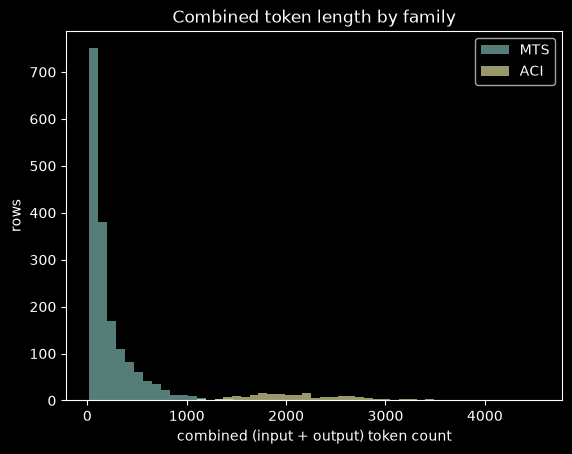


The combined p95/p99 above is what sets max_seq_length for training.


In [11]:
if MEDGEMMA_OK:
    # family -> (input_col, output_col)
    FAMILY_COLS = {"MTS": ("dialogue", "section_text"), "ACI": ("dialogue", "note")}

    def n_tokens(text):
        return len(tokenizer.encode(str(text), add_special_tokens=False))

    stats_rows = []
    combined_by_family = {}
    token_frames = {}  # family -> per-row df w/ split, in/out cols, token counts
    for family, (in_col, out_col) in FAMILY_COLS.items():
        # keep the split label per row so extreme examples are traceable back
        # to a specific file (see the extreme-value inspection cell below).
        parts = [df.assign(__split=name) for name, df in dfs.items()
                 if name.split("/")[0] == family]
        family_df = pd.concat(parts, ignore_index=True)
        in_toks = family_df[in_col].astype(str).map(n_tokens)
        out_toks = family_df[out_col].astype(str).map(n_tokens)
        # combined = input_tokens + output_tokens (approximation): the real
        # chat-template instruction overhead is small relative to 3-4k token
        # budgets, and the exact template is frozen later on Day 3.
        combined = in_toks + out_toks
        combined_by_family[family] = combined
        family_df["in_tok"], family_df["out_tok"], family_df["combined_tok"] = \
            in_toks, out_toks, combined
        family_df["__in_col"], family_df["__out_col"] = in_col, out_col
        token_frames[family] = family_df
        for label, toks in [("input", in_toks), ("output", out_toks), ("combined", combined)]:
            stats_rows.append({
                "family": family, "field": label, "n": len(toks),
                "min": int(toks.min()), "mean": round(toks.mean(), 1),
                "p50": int(toks.quantile(0.50)), "p90": int(toks.quantile(0.90)),
                "p95": int(toks.quantile(0.95)), "p99": int(toks.quantile(0.99)),
                "max": int(toks.max()),
            })

    token_stats = pd.DataFrame(stats_rows)
    print(token_stats.to_string(index=False))

    import matplotlib.pyplot as plt
    fig, ax = plt.subplots()
    for family, vals in combined_by_family.items():
        ax.hist(vals, bins=40, alpha=0.6, label=family)
    ax.set_xlabel("combined (input + output) token count")
    ax.set_ylabel("rows")
    ax.set_title("Combined token length by family")
    ax.legend()
    plt.show()

    print("\nThe combined p95/p99 above is what sets max_seq_length for training.")
else:
    print("MedGemma processor unavailable - token-length stats skipped.")

In [12]:
# Extreme-value inspection: pull the actual text behind the min/max token
# counts above, so "output min=2" or "combined max=4551" can be read and a
# handling decision made (drop / keep / truncate). K rows from each tail.
K = 3
ID_COL = {"MTS": "ID", "ACI": "encounter_id"}

def show(row, field):
    in_col, out_col = row["__in_col"], row["__out_col"]
    ident = row[ID_COL[row["__split"].split("/")[0]]]
    print(f"  [{row['__split']} {ident}]  in={row['in_tok']} out={row['out_tok']} "
          f"combined={row['combined_tok']}  (sorting by {field})")
    # short tails: show full text so degenerate rows are obvious; long tails:
    # head only (the point is length + that it's real text, not corruption).
    for col in (in_col, out_col):
        txt = str(row[col])
        shown = txt if len(txt) <= 400 else txt[:400] + f" …(+{len(txt)-400} chars)"
        print(f"    {col}: {shown!r}")
    print()

if MEDGEMMA_OK:
    for family, fdf in token_frames.items():
        for field in ("input", "output", "combined"):
            col = {"input": "in_tok", "output": "out_tok", "combined": "combined_tok"}[field]
            s = fdf.sort_values(col)
            print(f"===== {family} — {K} SHORTEST by {field} =====")
            for _, r in s.head(K).iterrows():
                show(r, field)
            print(f"===== {family} — {K} LONGEST by {field} =====")
            for _, r in s.tail(K).iloc[::-1].iterrows():
                show(r, field)
else:
    print("MedGemma processor unavailable - extreme-value inspection skipped.")

===== MTS — 3 SHORTEST by input =====
  [MTS/train 1013]  in=12 out=6 combined=18  (sorting by input)
    dialogue: 'Doctor: You can take Ibuprofen as needed for pain.'
    section_text: 'Ibuprofen PRN.'

  [MTS/valid 80]  in=12 out=2 combined=14  (sorting by input)
    dialogue: 'Doctor: Any past surgeries? \nPatient: Nah.'
    section_text: 'None.'

  [MTS/train 460]  in=13 out=5 combined=18  (sorting by input)
    dialogue: 'Doctor: Any drug allergies? \r\nPatient: No.'
    section_text: 'No known drug allergies.'

===== MTS — 3 LONGEST by input =====
  [MTS/train 1115]  in=2297 out=1335 combined=3632  (sorting by input)
    dialogue: "Doctor: Hello, miss. Doctor X and I will be going over your medical history with you. Before we begin, could you confirm your age for me?\r\nPatient: I'm twenty five years old. \r\nDoctor: Thank you. Doctor X, could you go over the diagnosis of erythema nodosum?\r\nDoctor_2: She was diagnosed in two thousand and four after a biopsy was done that confi

In [13]:
import re

# Degenerate MTS section_text scan — surfaces candidate DROP rows for Day-3
# data_prep, WITHOUT auto-dropping. Two independent signals:(shows output tokens).
#   pure_null : normalized output is a placeholder with no clinical content
#   short     : <=2 tokens (MedGemma tokenizer if loaded, else whitespace words)
# Length alone is NOT a drop reason: short-but-valid rows like ID 459/460
# (a 2-item med list, "No known drug allergies.") are the canonical MTS task.
# The point is to eyeball where real junk sits vs. where valid-short sits.
JUNK = {"", "none", "n/a", "na", "n.a.", "nil", "not applicable", "no", "-", "."}

def _norm(t):
    return re.sub(r"\s+", " ", str(t).lower()).strip()

mts_splits = ["MTS/train", "MTS/valid", "MTS/test1", "MTS/test2"]
flagged = []
for name in mts_splits:
    for _, row in dfs[name].iterrows():
        st = row["section_text"]
        norm = _norm(st)
        n_tok = n_tokens(st) if (MEDGEMMA_OK and tokenizer is not None) else len(norm.split())
        pure_null = norm in JUNK
        if pure_null or n_tok <= 2:
            flagged.append({
                "split": name, "ID": row["ID"], "header": row["section_header"],
                "n_tok": n_tok, "pure_null": pure_null,
                "section_text": st if len(str(st)) <= 80 else str(st)[:80] + "…",
            })

flagged_df = pd.DataFrame(flagged)
total = sum(len(dfs[n]) for n in mts_splits)
print(f"MTS rows flagged (pure-null OR <=2 tokens): {len(flagged_df)} of {total}")
if len(flagged_df):
    print(f"  pure-null placeholders (recommend DROP): {int(flagged_df['pure_null'].sum())}")
    print(f"  short only, not null (EYEBALL — may be valid, do not blind-drop): "
          f"{int((~flagged_df['pure_null']).sum())}\n")
    print(flagged_df.sort_values(["pure_null", "n_tok"], ascending=[False, True]).to_string(index=False))
else:
    print("  none flagged.")

MTS rows flagged (pure-null OR <=2 tokens): 79 of 1701
  pure-null placeholders (recommend DROP): 0
  short only, not null (EYEBALL — may be valid, do not blind-drop): 79

    split   ID        header  n_tok  pure_null section_text
MTS/train   12   MEDICATIONS      2      False        None.
MTS/train   19   MEDICATIONS      2      False        None.
MTS/train   77     FAM/SOCHX      2      False    Negative.
MTS/train   94     FAM/SOCHX      2      False    Negative.
MTS/train  109   MEDICATIONS      2      False        None.
MTS/train  136     FAM/SOCHX      2      False        None.
MTS/train  147 PASTMEDICALHX      2      False    Negative.
MTS/train  151   DISPOSITION      2      False      Stable.
MTS/train  163 PASTMEDICALHX      2      False        None.
MTS/train  173   MEDICATIONS      2      False        None.
MTS/train  195   MEDICATIONS      2      False        None.
MTS/train  229    PROCEDURES      2      False        None.
MTS/train  238   MEDICATIONS      2      False  

### Cross-split leakage checks

`encounter_id` overlap across ACI splits, plus exact-hash matching of
normalized dialogue text, both within ACI (train_pool vs. frozen_test) and
within MTS-Dialog (train vs. test1+test2). Fuzzy near-duplicate detection
(rapidfuzz on a cc+age+gender fingerprint) is deferred to the Day-3
data_prep step — exact-hash + id-overlap is sufficient for this EDA pass.

In [14]:
import hashlib
import re

# zero-width chars regex '\s' does NOT match, so strip them explicitly before
# collapsing whitespace, else they silently defeat exact-hash dedup.
ZERO_WIDTH = {0x200B, 0x200C, 0x200D, 0xFEFF}  # ZWSP, ZWNJ, ZWJ, BOM
_ZW_DELETE = {cp: None for cp in ZERO_WIDTH}

def norm_text(text):
    """lowercase + strip zero-width chars + collapse whitespace runs + strip"""
    text = str(text).lower().translate(_ZW_DELETE)
    return re.sub(r"\s+", " ", text).strip()

def hash_text(text):
    return hashlib.sha256(norm_text(text).encode("utf-8")).hexdigest()

# --- 1) encounter_id overlap across ACI splits ---
train_pool_ids = set()
for n, r in ACI_ROLE.items():
    if r == "train_pool":
        train_pool_ids |= set(dfs[n]["encounter_id"])
frozen_ids = set(dfs["ACI/test"]["encounter_id"])
id_overlap = train_pool_ids & frozen_ids
print(f"ACI encounter_id overlap (train_pool vs frozen_test): {len(id_overlap)}")
assert not id_overlap, f"encounter_id leakage across ACI splits: {id_overlap}"

# --- 2) exact-hash of normalized dialogue: ACI train_pool vs frozen_test ---
train_pool_hashes = {}
for n, r in ACI_ROLE.items():
    if r == "train_pool":
        for eid, dlg in zip(dfs[n]["encounter_id"], dfs[n]["dialogue"]):
            train_pool_hashes.setdefault(hash_text(dlg), []).append(eid)

frozen_hashes = {}
for eid, dlg in zip(dfs["ACI/test"]["encounter_id"], dfs["ACI/test"]["dialogue"]):
    frozen_hashes.setdefault(hash_text(dlg), []).append(eid)

aci_collisions = set(train_pool_hashes) & set(frozen_hashes)
print(f"ACI exact-dialogue-hash collisions (train_pool vs frozen_test): {len(aci_collisions)}")
for h in aci_collisions:
    print(f"  train_pool ids {train_pool_hashes[h]}  <->  frozen ids {frozen_hashes[h]}")

# --- 3) exact-hash of normalized dialogue: MTS train vs test1+test2 ---
mts_train_hashes = {}
for id_, dlg in zip(dfs["MTS/train"]["ID"], dfs["MTS/train"]["dialogue"]):
    mts_train_hashes.setdefault(hash_text(dlg), []).append(id_)

mts_test = pd.concat([dfs["MTS/test1"], dfs["MTS/test2"]], ignore_index=True)
mts_test_hashes = {}
for id_, dlg in zip(mts_test["ID"], mts_test["dialogue"]):
    mts_test_hashes.setdefault(hash_text(dlg), []).append(id_)

mts_collisions = set(mts_train_hashes) & set(mts_test_hashes)
print(f"MTS exact-dialogue-hash collisions (train n={len(dfs['MTS/train'])} vs "
      f"test1+test2 n={len(mts_test)}): {len(mts_collisions)}")

ACI encounter_id overlap (train_pool vs frozen_test): 0
ACI exact-dialogue-hash collisions (train_pool vs frozen_test): 0
MTS exact-dialogue-hash collisions (train n=1201 vs test1+test2 n=400): 2


In [15]:
# Inspect the 2 MTS collisions: show section_header + section_text on both
# sides (same dialogue can be split into different sections across train/test).
mts_train_by_id = dfs["MTS/train"].set_index("ID")
mts_test_by_id = mts_test.set_index("ID")

for h in mts_collisions:
    print("=" * 70)
    print(f"dialogue[:120]: {norm_text(mts_train_by_id.loc[mts_train_hashes[h][0], 'dialogue'])[:120]!r}")

    for tr_id in mts_train_hashes[h]:
        train_matches = mts_train_by_id[mts_train_by_id.index == tr_id]
        for _, row in train_matches.iterrows():
            print(f"  TRAIN ID {tr_id:>4}  {str(row['section_header']):<14} -> {str(row['section_text'])!r}")

    for te_id in mts_test_hashes[h]:
        test_matches = mts_test_by_id[mts_test_by_id.index == te_id]
        for _, row in test_matches.iterrows():
            print(f"  TEST  ID {te_id:>4}  {str(row['section_header']):<14} -> {str(row['section_text'])!r}")


dialogue[:120]: 'doctor: do you have any known drug allergies? patient: no.'
  TRAIN ID  926  ALLERGY        -> 'None.'
  TEST  ID  106  ALLERGY        -> 'She has no known drug allergies.'
  TEST  ID  106  FAM/SOCHX      -> 'Mother is 61 years old and brother is 39 years old, both alive and well. Father died at 48 of colon cancer and questionable pancreatic cancer. One paternal uncle died at 32 of colon cancer and bile duct cancer. One paternal uncle had colon cancer in his 40s. Thirty cancers are noted on the fathers side of the family, many are colon; two women had breast cancer. The family was told that there is a genetic syndrome in the family, but no one remembers the name of the syndrome.'
dialogue[:120]: 'doctor: do you have any known allergies to medications? patient: no.'
  TRAIN ID  901  ALLERGY        -> 'None.'
  TRAIN ID  989  ALLERGY        -> 'No known drug allergies.'
  TEST  ID   59  FAM/SOCHX      -> 'Mother and 2 maternal aunts with asthma. No history of renal or rh

### Encoding / mojibake scan

Non-ASCII character counts per text column, plus a targeted search for known
mojibake substrings (UTF-8-as-Latin-1 artifacts) so the Day-3 `ftfy` cleanup
target is concrete rather than guessed at.

In [16]:
import unicodedata
from collections import Counter

MOJIBAKE_PATTERNS = ["â€¢", "Ã", "â€™", "â€"]
TEXT_COLUMNS = {"dialogue", "note", "section_text"}

def char_label(ch):
    try:
        name = unicodedata.name(ch)
    except ValueError:
        name = "<unnamed>"
    return f"U+{ord(ch):04X} {name}"

mojibake_rows = []
for name, df in dfs.items():
    for col in df.columns:
        if col not in TEXT_COLUMNS:
            continue
        s = df[col].astype(str)
        nonascii_count = int(s.str.contains(r"[^\x00-\x7f]", regex=True, na=False).sum())
        if nonascii_count:
            print(f"{name:18s} {col:14s} non-ASCII rows: {nonascii_count}")
            # tally the actual non-ASCII characters so the ftfy target is concrete
            chars = Counter(c for txt in s for c in txt if ord(c) > 127)
            for ch, cnt in chars.most_common():
                print(f"       {ch!r:>6}  {char_label(ch):<34} x{cnt}")
        for pat in MOJIBAKE_PATTERNS:
            pat_mask = s.str.contains(re.escape(pat), regex=True, na=False)
            pat_count = int(pat_mask.sum())
            if pat_count:
                print(f"  -> mojibake {pat!r} found in {pat_count} row(s)")
                for ex in s[pat_mask].head(2):
                    print(f"     e.g. {ex[:150]!r}")
                mojibake_rows.append({"split": name, "col": col, "pattern": pat, "rows": pat_count})

if mojibake_rows:
    print("\nMojibake summary:")
    print(pd.DataFrame(mojibake_rows).to_string(index=False))
else:
    print("\nNo known mojibake substrings found (non-ASCII rows above may still be "
          "legitimate accented text, e.g. names).")

MTS/train          dialogue       non-ASCII rows: 6
          '”'  U+201D RIGHT DOUBLE QUOTATION MARK x5
          '…'  U+2026 HORIZONTAL ELLIPSIS         x3
          '“'  U+201C LEFT DOUBLE QUOTATION MARK  x3
          '—'  U+2014 EM DASH                     x1
          '‚'  U+201A SINGLE LOW-9 QUOTATION MARK x1
ACI/train          note           non-ASCII rows: 30
          '•'  U+2022 BULLET                      x258
          '’'  U+2019 RIGHT SINGLE QUOTATION MARK x17
       '\u202f'  U+202F NARROW NO-BREAK SPACE       x10
          '“'  U+201C LEFT DOUBLE QUOTATION MARK  x6
          '”'  U+201D RIGHT DOUBLE QUOTATION MARK x6
          'ß'  U+00DF LATIN SMALL LETTER SHARP S  x1
ACI/taskB_test1    note           non-ASCII rows: 18
          '•'  U+2022 BULLET                      x130
          '’'  U+2019 RIGHT SINGLE QUOTATION MARK x6
          '“'  U+201C LEFT DOUBLE QUOTATION MARK  x6
          '”'  U+201D RIGHT DOUBLE QUOTATION MARK x6
       '\u202f'  U+202F NARROW NO-BREAK

### Section-header coverage vs. `Norm_sec_head.txt`

Parses both line formats in the mapping file (`key [FULL NAME]` and bare
`key`), matches case-insensitively, and asserts every `section_header` value
across all 4 MTS splits resolves to a full name.

In [17]:
def load_section_map(path):
    """Parse 'key [FULL NAME]' or bare 'key' lines into {key: full_name} (lowercase keys)."""
    mapping = {}
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            m = re.match(r"^(\S+)(?:\s+\[(.+)\])?$", line)
            if not m:
                continue
            key, bracket = m.group(1), m.group(2)
            mapping[key.lower()] = (bracket or key).strip()
    return mapping

SECTION_MAP = load_section_map(DB / "Norm_sec_head.txt")

mts_splits = ["MTS/train", "MTS/valid", "MTS/test1", "MTS/test2"]
all_headers = set()
for n in mts_splits:
    all_headers |= set(dfs[n]["section_header"].str.lower())

unmapped = sorted(h for h in all_headers if h not in SECTION_MAP)
assert not unmapped, f"section_header values missing from Norm_sec_head.txt: {unmapped}"

header_table = pd.DataFrame(
    [{"section_header": h, "full_name": SECTION_MAP[h]} for h in sorted(all_headers)]
)
print(f"All {len(all_headers)} distinct MTS section_header values resolve in Norm_sec_head.txt.\n")
header_table

All 20 distinct MTS section_header values resolve in Norm_sec_head.txt.



,section_header,full_name
0,allergy,allergy
1,assessment,assessment
2,cc,CHIEF COMPLAINT
3,diagnosis,diagnosis
4,disposition,disposition
5,edcourse,EMERGENCY DEPARTMENT COURSE
6,exam,exam
7,fam/sochx,FAMILY HISTORY/SOCIAL HISTORY
8,genhx,HISTORY of PRESENT ILLNESS
9,gynhx,GYNECOLOGIC HISTORY


In [18]:
# One full ACI note, plus the UPPERCASE section headers embedded inside it.
sample_note = dfs["ACI/train"]["note"].iloc[0]
print(sample_note)
print("\n" + "=" * 60)

header_pattern = re.compile(r"^[A-Z][A-Z0-9 /&]{2,}$", re.MULTILINE)
found_headers = header_pattern.findall(sample_note)
print("Embedded section headers found via regex:", found_headers)

CHIEF COMPLAINT

Annual exam.

HISTORY OF PRESENT ILLNESS

Martha Collins is a 50-year-old female with a past medical history significant for congestive heart failure, depression, and hypertension who presents for her annual exam. It has been a year since I last saw the patient.

The patient has been traveling a lot recently since things have gotten a bit better. She reports that she got her COVID-19 vaccine so she feels safer about traveling. She has been doing a lot of hiking.

She reports that she is staying active. She has continued watching her diet and she is doing well with that. The patient states that she is avoiding salty foods that she likes to eat. She has continued utilizing her medications. The patient denies any chest pain, shortness of breath, or swelling in her legs.

Regarding her depression, she reports that she has been going to therapy every week for the past year. This has been really helpful for her. She denies suicidal or homicidal ideation.

The patient reports

These are the same section types MTS-Dialog trains on individually (e.g.
`CC`, `GENHX`, `EXAM`, `ASSESSMENT`/`PLAN`). This is the basis of the
project's mixed-granularity design: MTS teaches the model to produce one
section well, ACI teaches it to assemble many sections into a full note.

In [19]:
# ACI uses [doctor]/[patient] tags; MTS-Dialog uses "Doctor:"/"Patient:" with
# literal \r\n line endings. This mismatch is the Day-3 speaker-tag
# normalization target.
aci_snippet = dfs["ACI/train"]["dialogue"].iloc[0][:300]
mts_snippet = dfs["MTS/train"]["dialogue"].iloc[0][:300]

print("--- ACI dialogue snippet ---")
print(repr(aci_snippet))
print("\n--- MTS dialogue snippet ---")
print(repr(mts_snippet))

--- ACI dialogue snippet ---
"[doctor] hi , martha . how are you ?\n[patient] i'm doing okay . how are you ?\n[doctor] i'm doing okay . so , i know the nurse told you about dax . i'd like to tell dax a little bit about you , okay ?\n[patient] okay .\n[doctor] martha is a 50-year-old female with a past medical history significant for"

--- MTS dialogue snippet ---
'Doctor: What brings you back into the clinic today, miss? \r\nPatient: I came in for a refill of my blood pressure medicine. \r\nDoctor: It looks like Doctor Kumar followed up with you last time regarding your hypertension, osteoarthritis, osteoporosis, hypothyroidism, allergic rhinitis and kidney stone'
